# JobPulseKE — NLP Analysis (v2, on full cleaned dataset)

This notebook runs the NLP stage (skill extraction, metadata extraction, classification, topic modelling) on the current dataset: `data/processed/jobpulse_cleaned_20260831_220832.parquet` (10,379 records, 100% non-null `job_description`).

**Important finding checked before anything else runs:** `job_description` being 100% non-null does not mean 100% of rows have real text — several sources were backfilled with a literal `"No description"` placeholder rather than actual scraped content. This notebook detects that explicitly and treats placeholder rows differently from real-content rows throughout, so the numbers reported here reflect what the data can actually support.

## 1. Setup

In [4]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup


PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.nlp.skill_extractor import get_extractor
from src.nlp.metadata_extractor import get_metadata_extractor, SeniorityLevel

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.facecolor"] = "white"


## 2. Load data

In [5]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "jobpulse_cleaned_20260831_220832.parquet"
df = pd.read_parquet(DATA_PATH)

print(f"Rows: {len(df):,}   Columns: {len(df.columns)}")
df.head(3)


Rows: 10,379   Columns: 22


,job_id,source,source_job_id,job_title,company,job_description,location,country,work_mode,remote_scope,...,employment_type,experience_required,education_required,salary,currency,date_posted,application_deadline,tech_category,vacancy_url,scraped_at
0,bbd20f21c744b6fb,brightermonday,office-admin-pgdzvv,OFFICE ADMIN,None,OFFICE ADMIN,None,Kenya,unknown,None,...,None,None,None,None,None,None,NaN,None,https://www.brightermonday.co.ke/listings/office-admin-pgdzvv,2026-08-30T15:41:00+00:00
1,e7b1c86afa914d37,brightermonday,lead-baker-5p6jmp,LEAD BAKER,None,LEAD BAKER,None,Kenya,unknown,None,...,None,None,None,None,None,None,NaN,None,https://www.brightermonday.co.ke/listings/lead-baker-5p6jmp,2026-08-30T15:41:00+00:00
2,8c65dfc4609af714,brightermonday,sales-marketing-qz4jm6,Sales & Marketing,None,Sales & Marketing,None,Kenya,unknown,None,...,None,None,None,None,None,None,NaN,None,https://www.brightermonday.co.ke/listings/sales-marketing-qz4jm6,2026-08-30T15:41:00+00:00


## 3. Data quality report

In [6]:
PLACEHOLDER_STRINGS = {
    "no description", "n/a", "none", "not available", "description not available", "",
}
MIN_REAL_LENGTH = 40  # characters; short enough to allow terse real postings, long enough to exclude placeholders

def is_real_description(text: str) -> bool:
    if not isinstance(text, str):
        return False
    cleaned = text.strip().lower()
    if cleaned in PLACEHOLDER_STRINGS:
        return False
    if len(text.strip()) < MIN_REAL_LENGTH:
        return False
    return True

df["has_real_description"] = df["job_description"].apply(is_real_description)

overall_pct = df["has_real_description"].mean() * 100
print(f"Rows with a REAL description: {df['has_real_description'].sum():,} / {len(df):,} ({overall_pct:.1f}%)")


Rows with a REAL description: 1,118 / 10,379 (10.8%)


In [7]:
coverage_by_source = (
    df.groupby("source")["has_real_description"]
      .agg(total="count", real="sum")
)
coverage_by_source["pct_real"] = (coverage_by_source["real"] / coverage_by_source["total"] * 100).round(1)
coverage_by_source = coverage_by_source.sort_values("total", ascending=False)
coverage_by_source


,total,real,pct_real
source,,,
fantastic_jobs_hf,5374,0,0.0
jobberman,1939,0,0.0
linkedin,1147,0,0.0
hotnigerianjobs,813,813,100.0
myjobmag,654,0,0.0
indeed,110,0,0.0
fuzu,90,89,98.9
brightermonday,74,47,63.5
jobicy,71,71,100.0


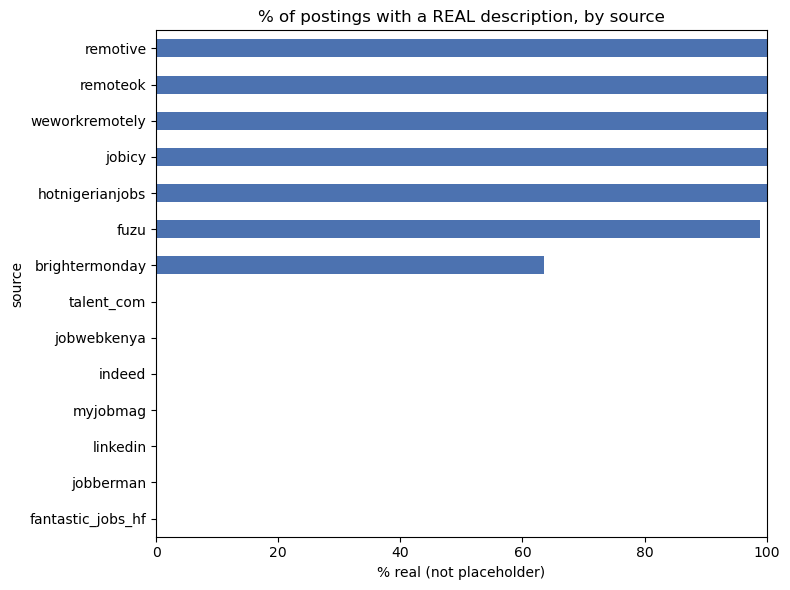

In [8]:
coverage_by_source["pct_real"].sort_values().plot(kind="barh", figsize=(8, 6), color="#4C72B0")
plt.title("% of postings with a REAL description, by source")
plt.xlabel("% real (not placeholder)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


### `tech_category` label quality

In [9]:
print("Before normalization:")
print(df["tech_category"].value_counts(dropna=False))

CATEGORY_NORMALIZATION = {
    "Cloud & DevOps": "DevOps & Cloud",
    "Product & UX": "Product & Design",
}
df["tech_category"] = df["tech_category"].replace(CATEGORY_NORMALIZATION)

print("\nAfter normalization:")
print(df["tech_category"].value_counts(dropna=False))


Before normalization:
tech_category
Other Tech                 3974
None                       2432
Software Development       1685
Data & AI                  1036
Software & IT               379
IT Support & Networking     196
QA & Testing                190
Product & Design            160
Cybersecurity               144
DevOps & Cloud              121
Product & UX                 26
Cloud & DevOps               21
Networking                   15
Name: count, dtype: int64

After normalization:
tech_category
Other Tech                 3974
None                       2432
Software Development       1685
Data & AI                  1036
Software & IT               379
IT Support & Networking     196
QA & Testing                190
Product & Design            186
Cybersecurity               144
DevOps & Cloud              142
Networking                   15
Name: count, dtype: int64


## 4. Text cleaning

In [10]:
def clean_text(raw: str) -> str:
    if not isinstance(raw, str) or not raw.strip():
        return ""
    # Strip HTML tags if present
    if "<" in raw and ">" in raw:
        raw = BeautifulSoup(raw, "html.parser").get_text(separator=" ")
    return " ".join(raw.split())

df["title_clean"] = df["job_title"].apply(clean_text)

# Only feed REAL description text into the NLP text field — placeholder text
# ("No description") would otherwise silently pollute every downstream result.
df["desc_clean"] = np.where(
    df["has_real_description"],
    df["job_description"].apply(clean_text),
    ""
)

df["text_for_nlp"] = (df["title_clean"] + " " + df["desc_clean"]).str.strip()

df.loc[df["has_real_description"], ["job_title", "desc_clean"]].sample(2, random_state=1)


,job_title,desc_clean
5706,Managed Services NOC Supervisor at Equinix Nigeria,Equinix Nigeria is recruiting to fill the position of: Managed Services NOC Supervisor. The position is located in L...
9581,Lead UX Designer | EMEA | Contract,"Location: Remote — EMEA (Open to applicants in Europe, the Middle East and Africa) Fueled is a leading digital strat..."


## 5. Skill extraction

In [11]:
extractor = get_extractor()

def extract_skill_list(text: str):
    skills_by_cat = extractor.extract_skills(text)
    return sorted({skill for skills in skills_by_cat.values() for skill in skills})

df["skills_found"] = df["text_for_nlp"].apply(extract_skill_list)
df["n_skills_found"] = df["skills_found"].apply(len)

for label, subset in [("Real-description rows", df[df["has_real_description"]]),
                       ("Title-only rows", df[~df["has_real_description"]])]:
    pct_matched = (subset["n_skills_found"] > 0).mean() * 100
    print(f"{label}: {len(subset):,} rows, {pct_matched:.1f}% matched at least one skill")


Real-description rows: 1,118 rows, 17.2% matched at least one skill
Title-only rows: 9,261 rows, 5.1% matched at least one skill


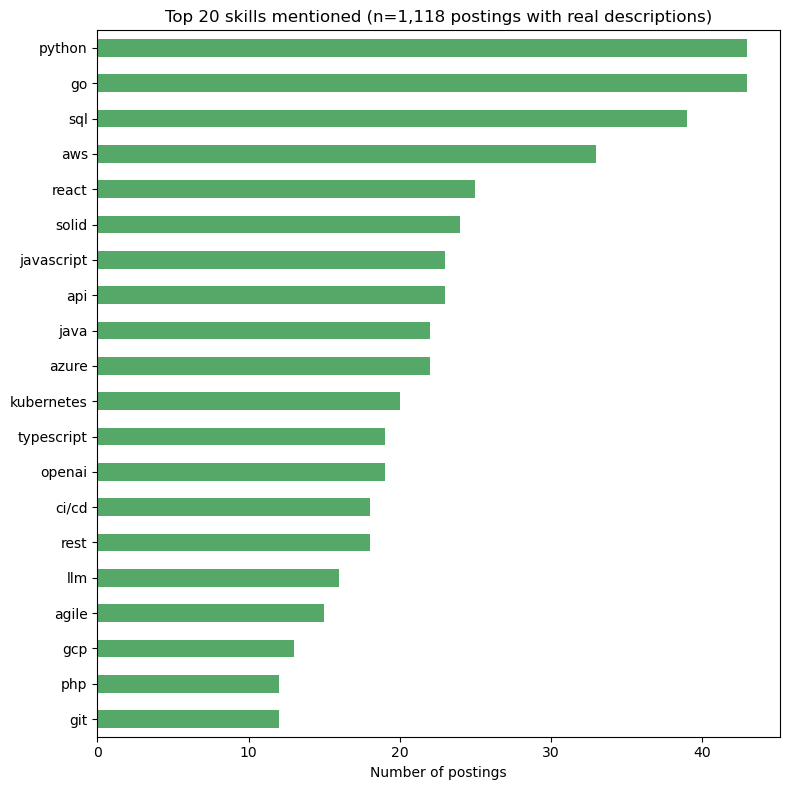

python        43
go            43
sql           39
aws           33
react         25
solid         24
javascript    23
api           23
java          22
azure         22
kubernetes    20
typescript    19
openai        19
ci/cd         18
rest          18
llm           16
agile         15
gcp           13
php           12
git           12
dtype: int64

In [12]:
from collections import Counter

# Restrict the "top skills" view to real-description rows only 
# skill hits are mostly just the job title repeating a language/tool name and
# would skew frequencies (e.g. every "SQL Developer" title counted as a full "SQL" mention).
real_df = df[df["has_real_description"]].copy()

skill_counts = Counter(s for skills in real_df["skills_found"] for s in skills)
top_skills = pd.Series(dict(skill_counts)).sort_values(ascending=False).head(20)

top_skills.plot(kind="barh", figsize=(8, 8), color="#55A868")
plt.title(f"Top 20 skills mentioned (n={len(real_df):,} postings with real descriptions)")
plt.xlabel("Number of postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_skills


In [13]:
# Skills by tech_category, real-description rows only
exploded = real_df.explode("skills_found").dropna(subset=["skills_found"])
skill_by_cat = exploded.groupby(["tech_category", "skills_found"]).size().reset_index(name="count")

for cat in real_df["tech_category"].dropna().unique():
    top = skill_by_cat[skill_by_cat["tech_category"] == cat].sort_values("count", ascending=False).head(5)
    if top.empty:
        continue
    print(f"\n{cat}:")
    print(top[["skills_found", "count"]].to_string(index=False))



Software Development:
skills_found  count
      python     19
          go     16
        java     16
       react     15
         aws     14

Other Tech:
       skills_found  count
              scrum      3
                aws      3
amazon web services      3
              agile      2
              mysql      2

Cybersecurity:
skills_found  count
         aws      1
       azure      1
         gcp      1
          go      1
google cloud      1

DevOps & Cloud:
skills_found  count
         aws      4
  kubernetes      3
       ci/cd      2
         sql      2
       solid      2

Data & AI:
skills_found  count
      python     12
         sql      6
       azure      5
         llm      5
          go      5

Product & Design:
skills_found  count
          go      5
         sql      4
       solid      2
       azure      1
         css      1

QA & Testing:
skills_found  count
       ci/cd      1

Software & IT:
skills_found  count
         sql     14
          go     11
  types

## 6. Metadata extraction

In [14]:
metadata_extractor = get_metadata_extractor()

df["employment_type"] = df["text_for_nlp"].apply(metadata_extractor.extract_employment_type)
df["work_mode"] = df["text_for_nlp"].apply(metadata_extractor.extract_work_mode)

print("Employment type (only reports what it actually detects):")
print(df["employment_type"].value_counts(dropna=False))
print(f"\nWork mode (only reports what it actually detects):")
print(df["work_mode"].value_counts(dropna=False))


Employment type (only reports what it actually detects):
employment_type
None          9957
Freelance      120
Full-Time       96
Contract        87
Internship      56
Part-Time       34
Temporary       29
Name: count, dtype: int64

Work mode (only reports what it actually detects):
work_mode
None       9731
Remote      517
Hybrid       78
On-Site      53
Name: count, dtype: int64


In [15]:
def has_explicit_seniority_keyword(title: str, description: str) -> bool:
    combined = f"{title} {description}".lower()
    return any(keyword in combined for keyword in metadata_extractor.SENIORITY_KEYWORDS)

df["seniority_keyword_found"] = df.apply(
    lambda r: has_explicit_seniority_keyword(r["title_clean"], r["desc_clean"]), axis=1
)

df["seniority_level"] = np.where(
    df["seniority_keyword_found"],
    df.apply(lambda r: metadata_extractor.extract_seniority_level(r["title_clean"], r["desc_clean"]).value, axis=1),
    "Unspecified"
)

print(f"Rows with an EXPLICIT seniority keyword: {df['seniority_keyword_found'].sum():,} / {len(df):,} "
      f"({df['seniority_keyword_found'].mean()*100:.1f}%)")
print()
print(df["seniority_level"].value_counts())


Rows with an EXPLICIT seniority keyword: 3,778 / 10,379 (36.4%)

seniority_level
Unspecified    6601
Lead           1383
Senior         1163
Executive       365
Intern          358
Entry Level     339
Mid-Level       170
Name: count, dtype: int64


## 7. Years of experience, education, certifications

In [16]:
real_df = df[df["has_real_description"]].copy()

real_df["years_experience"] = real_df["desc_clean"].apply(extractor.extract_years_experience)
real_df["education_required"] = real_df["desc_clean"].apply(extractor.extract_education)
real_df["certifications"] = real_df["desc_clean"].apply(extractor.extract_certifications)

has_exp = real_df[real_df["years_experience"] > 0]
print(f"Rows stating years of experience: {len(has_exp)} / {len(real_df)} ({len(has_exp)/len(real_df)*100:.1f}%)")
if len(has_exp) > 0:
    print(has_exp["years_experience"].describe())

edu_counts = Counter(e for edu_list in real_df["education_required"] for e in edu_list)
print("\nEducation requirements mentioned:", dict(edu_counts))

cert_counts = Counter(c for cert_list in real_df["certifications"] for c in cert_list)
print("Certifications mentioned:", dict(cert_counts))


Rows stating years of experience: 204 / 1118 (18.2%)
count    204.000000
mean       4.676471
std        2.632356
min        1.000000
25%        3.000000
50%        5.000000
75%        5.000000
max       18.000000
Name: years_experience, dtype: float64

Education requirements mentioned: {'Associate Degree': 545, 'Diploma/High School': 113, "Bachelor's Degree": 214, "Master's Degree": 273, 'PhD': 2}
Certifications mentioned: {'PMP': 3, 'AWS Certification': 44, 'Scrum Master': 3, 'Kubernetes Certification': 20, 'Azure Certification': 22, 'GCP Certification': 13, 'CISSP': 2}


## 8. Classification: predicting `tech_category` from text

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model_df = real_df.dropna(subset=["tech_category"]).copy()

MIN_ROWS_PER_CLASS = 8
class_counts = model_df["tech_category"].value_counts()
keep_classes = class_counts[class_counts >= MIN_ROWS_PER_CLASS].index
dropped_classes = class_counts[class_counts < MIN_ROWS_PER_CLASS]

model_df = model_df[model_df["tech_category"].isin(keep_classes)]

print(f"Usable rows for classification: {len(model_df)}")
print(f"Classes kept (>= {MIN_ROWS_PER_CLASS} rows): {list(keep_classes)}")
if len(dropped_classes) > 0:
    print(f"Classes dropped (too few rows to evaluate honestly): {dict(dropped_classes)}")
print()
print(model_df["tech_category"].value_counts())


Usable rows for classification: 652
Classes kept (>= 8 rows): ['Other Tech', 'Software Development', 'Software & IT', 'Data & AI', 'Product & Design', 'IT Support & Networking', 'DevOps & Cloud', 'Cybersecurity']
Classes dropped (too few rows to evaluate honestly): {'QA & Testing': 7}

tech_category
Other Tech                 208
Software Development       163
Software & IT              145
Data & AI                   68
Product & Design            19
IT Support & Networking     17
DevOps & Cloud              17
Cybersecurity               15
Name: count, dtype: int64


In [18]:
def run_classifier(text_column, label):
    X_train, X_test, y_train, y_test = train_test_split(
        model_df[text_column], model_df["tech_category"],
        test_size=0.25, random_state=42, stratify=model_df["tech_category"]
    )
    vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words="english", min_df=2)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X_train_vec, y_train)
    preds = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, preds)
    print(f"=== {label} — Accuracy: {acc:.3f} ===")
    print(classification_report(y_test, preds, zero_division=0))
    return acc

acc_with_title = run_classifier("text_for_nlp", "Title + Description")


=== Title + Description — Accuracy: 0.755 ===
                         precision    recall  f1-score   support

          Cybersecurity       0.33      0.50      0.40         4
              Data & AI       0.39      0.53      0.45        17
         DevOps & Cloud       0.67      0.50      0.57         4
IT Support & Networking       0.38      0.75      0.50         4
             Other Tech       0.89      0.79      0.84        52
       Product & Design       0.60      0.60      0.60         5
          Software & IT       0.94      0.92      0.93        36
   Software Development       0.81      0.73      0.77        41

               accuracy                           0.75       163
              macro avg       0.63      0.66      0.63       163
           weighted avg       0.79      0.75      0.77       163



In [19]:
acc_desc_only = run_classifier("desc_clean", "Description Only")

print(f"\nTitle+description accuracy: {acc_with_title:.3f}")
print(f"Description-only accuracy:  {acc_desc_only:.3f}")
print(f"Gap: {acc_with_title - acc_desc_only:.3f}")


=== Description Only — Accuracy: 0.718 ===
                         precision    recall  f1-score   support

          Cybersecurity       0.50      0.50      0.50         4
              Data & AI       0.33      0.47      0.39        17
         DevOps & Cloud       0.50      0.25      0.33         4
IT Support & Networking       0.20      0.50      0.29         4
             Other Tech       0.83      0.75      0.79        52
       Product & Design       0.60      0.60      0.60         5
          Software & IT       0.94      0.92      0.93        36
   Software Development       0.81      0.71      0.75        41

               accuracy                           0.72       163
              macro avg       0.59      0.59      0.57       163
           weighted avg       0.76      0.72      0.73       163


Title+description accuracy: 0.755
Description-only accuracy:  0.718
Gap: 0.037


## 9. Topic modelling 

In [20]:
from sklearn.decomposition import NMF

desc_corpus = real_df[real_df["desc_clean"].str.len() > 50]["desc_clean"]
print(f"Postings used for topic modelling: {len(desc_corpus)}")

tfidf_desc = TfidfVectorizer(max_features=1500, ngram_range=(1, 2), stop_words="english", min_df=2)
desc_vec = tfidf_desc.fit_transform(desc_corpus)

n_topics = 6
nmf = NMF(n_components=n_topics, random_state=42, init="nndsvda", max_iter=500)
nmf.fit(desc_vec)

desc_feature_names = tfidf_desc.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [desc_feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")


Postings used for topic modelling: 1114
Topic 0: position, recruiting position, interested candidates, candidates possess, possess, interested, position located, located, recruiting, candidates
Topic 1: kenya, jobs, engineering, jobs clear, clear filters, filters, seniority, published, level, management
Topic 2: job recruitment, recruitment, recruitment positions, job, positions, exp, exp job, limited job, limited, nigeria
Topic 3: ai, team, product, work, experience, ll, data, build, remote, technical
Topic 4: limited, technologies limited, technologies, officer, engineer, manager, hybrid, solutions, business solutions, solutions limited
Topic 5: share, lorem ipsum, lorem, ipsum, job, dolor, ipsum dolor, data, report, link
